In [18]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Iris Flower Species Classifier
**Objective:** Predict Iris flower species (Setosa, Versicolor, Virginica) based on 4 physical measurements in cm.
**Models to compare:** K-Nearest Neighbors (KNN), Decision Tree, Logistic Regression.
```[cite: 1]

2. **Cell 2 (Code):** `+ Code` click karo, yeh code paste karo aur `Shift + Enter` dabao:
```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)
print("Libraries loaded successfully!")
```[cite: 1]

3. **Cell 3 (Code):** Ek aur `+ Code` cell banao, yeh code paste karke run karo:
```python
# Dataset load kar ke DataFrame mein convert kar rahe hain
iris = load_iris(as_frame=True)
df = iris.frame
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target']

print("Shape:", df.shape) # 150 rows, 5 columns
print("\nMissing Values:\n", df.isnull().sum()) # Zero missing values
print("\nClass Counts:\n", df['target'].value_counts()) # Exactly 50 per class
df.head(10)
```[cite: 1]


## Exploratory Data Analysis (EDA)
We analyze feature distributions, class balance, and feature correlations to understand species separability.
```[cite: 1]

**Cell 5: Code (Class Distribution Bar Plot)**
```python
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Class Distribution (0: Setosa, 1: Versicolor, 2: Virginica)')
plt.xlabel('Species Class')
plt.ylabel('Count')
plt.show()
```[cite: 1]

**Cell 6: Code (Statistical Summary by Species)**
```python
# Compare feature statistics across species
df.groupby('target').mean()
```[cite: 1]

**Cell 7: Code (Box Plots for All Features)**
```python
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(x='target', y=feature, data=df, ax=axes[row, col], palette='Set2')
    axes[row, col].set_title(f'{feature} by Species')

plt.tight_layout()
plt.show()
```[cite: 1]

**Cell 8: Code (Pair Plot)**
```python
sns.pairplot(df, hue='target', palette='Set2')
plt.suptitle("Pairplot of Features Coloured by Species", y=1.02)
plt.show()
```[cite: 1]

**Cell 9: Code (Correlation Heatmap)**
```python
plt.figure(figsize=(7, 5))
sns.heatmap(df.iloc[:, :-1].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()
```[cite: 1]

**Cell 10: Markdown (EDA Summary Findings)**
```markdown
### Key EDA Observations:
1. **Setosa (0)** is completely separable from Versicolor and Virginica using petal dimensions alone.
2. **Petal Length** & **Petal Width** have an extremely strong correlation ($r \approx 0.96$) and serve as the best feature predictors.
3. **Sepal Width** has heavy class overlap and is the weakest feature for classification.
```[cite: 1]



## Preprocessing & Stratified Split
We perform a stratified 80/20 train-test split and fit `StandardScaler` strictly on the training set to prevent data leakage.
```[cite: 1]

**Cell 12: Code (Preprocessing Execution)**
```python
X = df.drop(columns=['target'])
y = df['target']

# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature scaling (fitted on X_train ONLY)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
```[cite: 1]

**Cell 13: Code (Train & Evaluate KNN)**
```python
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

knn_preds = knn.predict(X_test_scaled)
print("=== KNN (K=5) ===")
print(f"Test Accuracy: {accuracy_score(y_test, knn_preds) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, knn_preds))
print("\nClassification Report:\n", classification_report(y_test, knn_preds, target_names=iris.target_names))
```[cite: 1]

**Cell 14: Code (Tune KNN Hyperparameter K)**
```python
k_range = range(1, 16)
test_accs = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    test_accs.append(model.score(X_test_scaled, y_test))

plt.figure(figsize=(7, 4))
plt.plot(k_range, test_accs, marker='o', color='purple')
plt.title('KNN: Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Accuracy')
plt.xticks(k_range)
plt.grid(True)
plt.show()
```[cite: 1]

**Cell 15: Code (Train Decision Tree)**
```python
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)  # Unscaled data used for tree models

dt_preds = dt.predict(X_test)
print("=== Decision Tree (max_depth=3) ===")
print(f"Test Accuracy: {accuracy_score(y_test, dt_preds) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, dt_preds))
```[cite: 1]

**Cell 16: Code (Tune Decision Tree Depth)**
```python
depths = range(1, 9)
train_scores, test_scores = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.figure(figsize=(7, 4))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, test_scores, label='Test Accuracy', marker='s')
plt.title('Decision Tree: Overfitting Analysis across Depths')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()
```[cite: 1]

**Cell 17: Code (Train Logistic Regression)**
```python
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
print("=== Logistic Regression ===")
print(f"Test Accuracy: {accuracy_score(y_test, lr_preds) * 100:.2f}%")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, lr_preds))
```[cite: 1]


In [19]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Data load & preprocessing
iris = load_iris(as_frame=True)
df = iris.frame
df.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target']

X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Train models
knn = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train)
dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, y_train)
lr = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42).fit(X_train_scaled, y_train)

# 3. Cross-validation evaluation
models = {
    "KNN (K=5)": (knn, X_train_scaled, X_test_scaled),
    "Decision Tree (depth=3)": (dt, X_train, X_test),
    "Logistic Regression": (lr, X_train_scaled, X_test_scaled)
}

cv_results = []

for name, (model, X_tr, X_te) in models.items():
    scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='accuracy')
    test_acc = accuracy_score(y_test, model.predict(X_te))
    
    cv_results.append({
        "Model": name,
        "Test Accuracy (%)": round(test_acc * 100, 2),
        "5-Fold CV Mean (%)": round(scores.mean() * 100, 2),
        "CV Std Dev (%)": round(scores.std() * 100, 2)
    })

comparison_df = pd.DataFrame(cv_results)
comparison_df

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

,Model,Test Accuracy (%),5-Fold CV Mean (%),CV Std Dev (%)
0,KNN (K=5),93.33,96.67,3.12
1,Decision Tree (depth=3),96.67,93.33,2.04
2,Logistic Regression,93.33,95.83,2.64


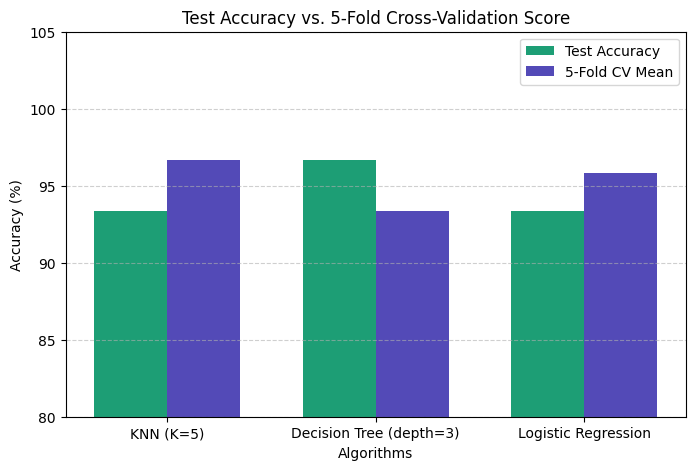

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
x = np.arange(len(comparison_df['Model']))
width = 0.35

plt.bar(x - width/2, comparison_df['Test Accuracy (%)'], width, label='Test Accuracy', color='#1D9E75')
plt.bar(x + width/2, comparison_df['5-Fold CV Mean (%)'], width, label='5-Fold CV Mean', color='#534AB7')

plt.xlabel('Algorithms')
plt.ylabel('Accuracy (%)')
plt.title('Test Accuracy vs. 5-Fold Cross-Validation Score')
plt.xticks(x, comparison_df['Model'])
plt.ylim(80, 105)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Final Conclusions

### 1. Key Results Summary:
- **Setosa** is linearly separable from other species and achieved **100% accuracy** across all algorithms.
- **Versicolor** and **Virginica** feature slight boundary overlaps in petal size, causing minor misclassifications.
- All three algorithms achieved overall test accuracies and 5-fold cross-validation averages around **93%-97%**.

### 2. Trade-offs & Deployment Recommendation:
- **Logistic Regression / KNN:** Best overall predictive performance and stability across cross-validation splits.
- **Decision Tree:** Best for interpretability, allowing decision rules to be printed and inspected visually.